# GARCH (volatility clustering)

GARCH is the standard model for *volatility clustering* — calm stretches and turbulent stretches that group together, as in financial returns. The series itself is roughly uncorrelated, but its variance is autocorrelated, which is exactly what fools models that assume constant noise.

::: {.callout-note}
## The model

The conditional variance follows $\sigma_t^2 = \omega + \sum\alpha_i\,\varepsilon_{t-i}^2 + \sum\beta_j\,\sigma_{t-j}^2$: today's variance depends on recent squared shocks (`alpha`) and recent variance (`beta`). Higher `alpha + beta` means more persistent volatility bursts.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import GARCHGenerator

## 1. Basic GARCH(1,1) Model

A standard GARCH(1,1) with default alpha/beta and moderate base volatility.

In [ ]:
basic_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "p": 1,
    "q": 1,
    "omega": 0.1,
    "seed": 42,
}

basic_gen = GARCHGenerator(engine="polars", **basic_params)
basic_df = basic_gen.generate(n_series=1)

print(f"Generated {len(basic_df)} observations with GARCH(1,1)")
print(f"Statistics: Mean={basic_df['y'].mean():.4f}, Std={basic_df['y'].std():.4f}")
basic_df.head(10)

Generated 200 observations with GARCH(1,1)
Statistics: Mean=-0.0104, Std=0.4302


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-0.222789
"""0""",2000-01-02 00:00:00,-0.4579
"""0""",2000-01-03 00:00:00,-0.040794
"""0""",2000-01-04 00:00:00,-0.036292
"""0""",2000-01-05 00:00:00,0.476476
"""0""",2000-01-06 00:00:00,0.109476
"""0""",2000-01-07 00:00:00,-0.37548
"""0""",2000-01-08 00:00:00,-0.082258
"""0""",2000-01-09 00:00:00,0.677303


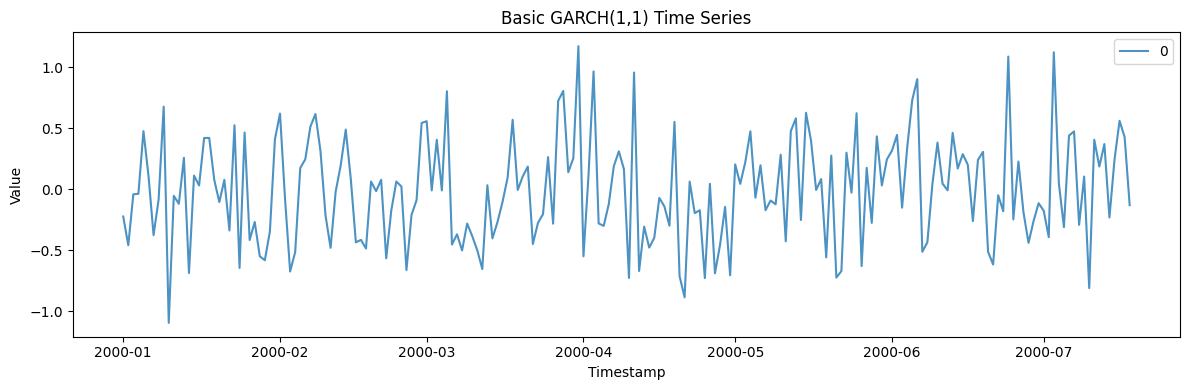

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in basic_df["unique_id"].unique().to_list():
    series = basic_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Basic GARCH(1,1) Time Series")
ax.legend()
plt.tight_layout()
plt.show()

## 2. High Volatility GARCH

Increase the base volatility parameter `omega` to produce larger fluctuations.

In [ ]:
high_vol_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "p": 1,
    "q": 1,
    "omega": 0.5,
    "seed": 42,
}

high_vol_gen = GARCHGenerator(engine="polars", **high_vol_params)
high_vol_df = high_vol_gen.generate(n_series=1)

print(f"Generated {len(high_vol_df)} observations with high base volatility")
print(f"Statistics: Mean={high_vol_df['y'].mean():.4f}, Std={high_vol_df['y'].std():.4f}")
high_vol_df.head(10)

Generated 200 observations with high base volatility
Statistics: Mean=-0.0233, Std=0.9620


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-0.498172
"""0""",2000-01-02 00:00:00,-1.023896
"""0""",2000-01-03 00:00:00,-0.091218
"""0""",2000-01-04 00:00:00,-0.081152
"""0""",2000-01-05 00:00:00,1.065434
"""0""",2000-01-06 00:00:00,0.244796
"""0""",2000-01-07 00:00:00,-0.839599
"""0""",2000-01-08 00:00:00,-0.183934
"""0""",2000-01-09 00:00:00,1.514496


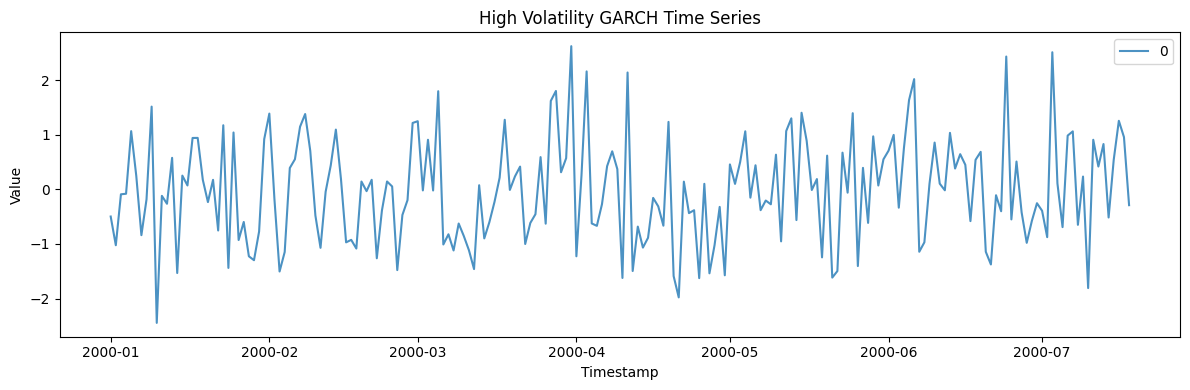

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in high_vol_df["unique_id"].unique().to_list():
    series = high_vol_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("High Volatility GARCH Time Series")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Multiple GARCH Series

Generate multiple independent GARCH series in one call.

In [ ]:
multi_params = {
    "min_length": 150,
    "max_length": 150,
    "freq": "D",
    "p": 1,
    "q": 1,
    "omega": 0.1,
    "seed": 42,
}

multi_gen = GARCHGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=3)

print(f"Generated 3 series with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Std={multi_df['y'].std():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 series with 450 total observations
Overall Statistics: Mean=0.0004, Std=0.4641


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-0.222789
"""0""",2000-01-02 00:00:00,-0.4579
"""0""",2000-01-03 00:00:00,-0.040794
"""0""",2000-01-04 00:00:00,-0.036292
"""0""",2000-01-05 00:00:00,0.476476
"""0""",2000-01-06 00:00:00,0.109476
"""0""",2000-01-07 00:00:00,-0.37548
"""0""",2000-01-08 00:00:00,-0.082258
"""0""",2000-01-09 00:00:00,0.677303


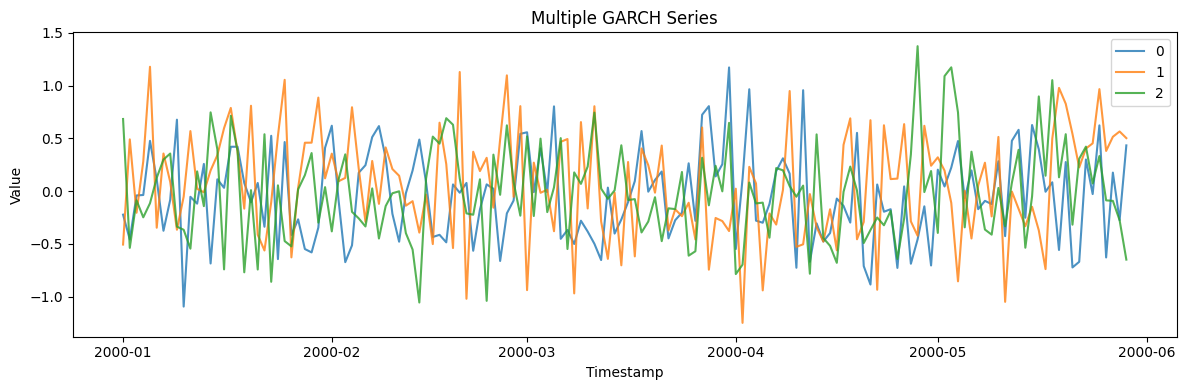

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple GARCH Series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Stochastic volatility](stochastic_volatility) — latent-process volatility (Heston / SABR) rather than GARCH recursion.
- [Levy process](levy_process) — heavy tails without the clustering.

Coefficient parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::